<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch18_simulation_of_financial_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 18 — Simulation of Financial Models

> *"The purpose of science is not to analyze or describe but to make useful models of the world."* — Edward de Bono

This notebook is the executable companion to **Chapter 18** of *Python for Finance, 2nd ed.* by Yves Hilpisch (O'Reilly, 2018). The chapter builds the **simulation layer** of the DX package — the engine that produces Monte Carlo paths for the financial models we will later price options against in Chapter 19.

Three stochastic processes are implemented, each chosen because it captures a structural feature of real markets that simpler models miss:

| Process | What it adds | Where it is used |
|---|---|---|
| **Geometric Brownian motion** (GBM) | Lognormal returns, constant volatility | Equities, FX (Black-Scholes baseline) |
| **Jump diffusion** (Merton 1976) | Sudden discrete jumps in price | Short-dated OTM options, event risk |
| **Square-root diffusion** (CIR 1985) | Mean reversion and positivity | Interest rates, stochastic variance |

The notebook is **self-contained**: it rebuilds the Chapter 17 framework prerequisites (`market_environment`, `constant_short_rate`) inline rather than importing the `dx` package, so it runs end-to-end on a fresh Colab kernel.

### How to read this notebook

Every code cell that produces output is followed by an explanation cell that does three things at minimum: states the **exact numbers**, links them to the **mathematics**, and frames the result in **production terms**. Mathematical notation follows the textbook's conventions.

### API divergence note

The textbook was written against pandas $\le$ 1.x. Pandas $\ge$ 2.2 removed several short-form frequency aliases. We patch this in `generate_time_grid()` by mapping `'M' \to 'ME'`, `'Q' \to 'QE'`, and `'A'/'Y' \to 'YE'`. The numerical output is identical to the textbook's; only the internal frequency string differs.

## 1  Setup

We need only `numpy`, `pandas`, and `matplotlib`. All other building blocks are written from scratch in this notebook.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 100

print('numpy  ', np.__version__)
print('pandas ', pd.__version__)


numpy   2.0.2
pandas  2.2.2


The library versions printed above are the **build-environment** versions; the textbook's code targets older versions but produces numerically identical results once the frequency-alias patch is in place.

## 2  DX framework prerequisites (Chapter 17 recap)

Chapter 18 builds on three components introduced in Chapter 17. We restate them here so this notebook is **self-contained** — readers who skipped Chapter 17 can still run everything end-to-end.

### 2.1  `get_year_deltas`

Year fractions are required everywhere in derivative pricing — discount factors, drift terms in SDEs, time-to-maturity adjustments. Given an ordered list of dates $t_0, t_1, \dots, t_M$, this helper returns

$$\Delta_m = \frac{(t_m - t_0)_{\text{days}}}{\texttt{day\_count}}, \qquad m = 0, 1, \dots, M.$$

A `day_count` of $365$ is the textbook convention (Act/365). In practice, fixed-income desks use Act/360, 30/360, or business-day counts depending on the asset class.

In [2]:
def get_year_deltas(date_list, day_count=365.):
    '''Year fractions between an ordered list of datetime objects.'''
    start = date_list[0]
    delta_list = [(date - start).days / day_count for date in date_list]
    return np.array(delta_list)


### 2.2  `constant_short_rate`

For a flat term structure, the continuously compounded discount factor between two dates separated by $\tau$ years is

$$D(\tau) = e^{-r \tau}.$$

We wrap the rate $r$ in a class so that later we can swap in deterministic or stochastic short-rate curves without touching the simulation classes — this is the **Liskov substitution principle** in action.

In [3]:
class constant_short_rate(object):
    '''Class for constant short rate discounting.'''
    def __init__(self, name, short_rate):
        self.name = name
        self.short_rate = short_rate
        if short_rate < 0:
            raise ValueError('Short rate negative.')

    def get_discount_factors(self, date_list, dtobjects=True):
        if dtobjects is True:
            dlist = get_year_deltas(date_list)
        else:
            dlist = np.array(date_list)
        dflist = np.exp(self.short_rate * np.sort(-dlist))
        return np.array((date_list, dflist)).T


### 2.3  `market_environment`

The `market_environment` is a typed dictionary holding everything a simulation or valuation routine needs: scalars (`constants`), curves (objects with discount methods), and lists (time grids, random-number arrays, Cholesky factors). It is the **single source of truth** passed between classes — a deliberate design choice that prevents argument-list explosion when models grow more parameters.

In [4]:
class market_environment(object):
    '''Container for market data: constants, curves, lists.'''
    def __init__(self, name, pricing_date):
        self.name = name
        self.pricing_date = pricing_date
        self.constants = {}
        self.lists = {}
        self.curves = {}

    def add_constant(self, key, constant):
        self.constants[key] = constant

    def get_constant(self, key):
        return self.constants[key]

    def add_list(self, key, list_object):
        self.lists[key] = list_object

    def get_list(self, key):
        return self.lists[key]

    def add_curve(self, key, curve):
        self.curves[key] = curve

    def get_curve(self, key):
        return self.curves[key]

    def add_environment(self, env):
        # overwrites existing values on key collision
        self.constants.update(env.constants)
        self.lists.update(env.lists)
        self.curves.update(env.curves)


These three components are now in scope. We turn next to the workhorse of every Monte Carlo engine: the random number generator.

## 3  Random number generation

Monte Carlo pricing replaces an unknown expectation under the equivalent martingale measure with a sample average:

$$\mathbb{E}^{\mathbb{Q}}\!\left[e^{-rT} h(S_T)\right] \;\approx\; \frac{1}{I} \sum_{i=1}^{I} e^{-rT} h\!\left(S_T^{(i)}\right).$$

The standard error of this estimator scales as $\sigma / \sqrt{I}$, so cutting it in half requires **quadrupling** the number of paths $I$. Variance reduction techniques attack the numerator $\sigma$ directly — a far better lever than throwing more compute at the denominator.

We implement two of the most reliable techniques:

**Antithetic variates.** For every standard normal draw $z$, also use $-z$. By symmetry $\mathbb{E}[z] = \mathbb{E}[-z] = 0$, but the **paired** estimator $\tfrac{1}{2}(h(z) + h(-z))$ has lower variance whenever $h$ is monotone, since $z$ and $-z$ are perfectly negatively correlated.

**Moment matching.** After drawing the raw sample $\{z_i\}$, we rescale:

$$\tilde{z}_i = \frac{z_i - \bar{z}}{s_z},$$

where $\bar{z}$ and $s_z$ are the sample mean and standard deviation. The transformed sample has **exact** first and second moments matching $\mathcal{N}(0,1)$, eliminating the sampling error in those moments. For small samples this matters enormously; for $I \to \infty$ the correction vanishes.

A `fixed_seed` flag locks the RNG state so simulation runs are bitwise reproducible — essential for regulatory replication of P&L attribution.

In [5]:
def sn_random_numbers(shape, antithetic=True, moment_matching=True,
                      fixed_seed=False):
    '''Standard normal random numbers with optional variance reduction.

    Parameters
    ----------
    shape : tuple (o, n, m)
        output array shape
    antithetic : bool
        if True, return half the draws and their negatives
    moment_matching : bool
        if True, rescale to exact mean 0 and std 1
    fixed_seed : bool
        if True, seed the RNG to 1000 for reproducibility
    '''
    if fixed_seed:
        np.random.seed(1000)
    if antithetic:
        ran = np.random.standard_normal(
            (shape[0], shape[1], shape[2] // 2))
        ran = np.concatenate((ran, -ran), axis=2)
    else:
        ran = np.random.standard_normal(shape)
    if moment_matching:
        ran = ran - np.mean(ran)
        ran = ran / np.std(ran)
    if shape[0] == 1:
        return ran[0]
    else:
        return ran


### 3.1  Without variance reduction

We start by inspecting raw draws — no antithetics, no moment matching — to see how far a tiny sample can drift from its target moments.

In [6]:
snrn = sn_random_numbers((2, 2, 2), antithetic=False,
                         moment_matching=False, fixed_seed=True)
snrn


array([[[-0.8044583 ,  0.32093155],
        [-0.02548288,  0.64432383]],

       [[-0.30079667,  0.38947455],
        [-0.1074373 , -0.47998308]]])

The output is an $\mathbf{8}$-element tensor of shape $(2, 2, 2)$. The values are deterministic given the fixed seed $1000$, so this exact array will appear every time the cell is run with these flags. Note the **first** value `-0.8044583` — the first draw from `np.random.standard_normal` after seeding to $1000$ — this is a useful fingerprint for verifying reproducibility across systems.

In [7]:
print('mean =', round(snrn.mean(), 6))
print('std  =', round(snrn.std(), 6))


mean = -0.045429
std  = 0.451876


With only $8$ draws, the sample mean is **$-0.045429$** (target: $0$) and the sample standard deviation is **$0.451876$** (target: $1$).

The standard error of the sample mean for $\mathcal{N}(0,1)$ draws is $\sigma_{\bar{z}} = 1/\sqrt{n} = 1/\sqrt{8} \approx 0.354$. Our observed deviation of $-0.045$ is well within one standard error, so nothing is broken — the sample is just small.

The **standard deviation** estimate is dramatically biased, however: $0.452$ versus target $1.0$, a $55\%$ shortfall. This is the classic Bessel-correction territory plus small-sample sampling noise in the variance estimator (which has chi-squared distribution with $n-1$ degrees of freedom).

**Production framing:** for $I = 10{,}000$ paths the corresponding standard error of the mean is $1/\sqrt{10{,}000} = 0.01$, so the raw-draw bias contribution to the Monte Carlo error is already small. Moment matching becomes most valuable when you cannot afford many paths — e.g., real-time risk calculations on a trading desk.

### 3.2  With moment matching

Now we turn on `moment_matching=True` and rerun.

In [8]:
snrn = sn_random_numbers((2, 2, 2), antithetic=False,
                         moment_matching=True, fixed_seed=True)
snrn


array([[[-1.67972865,  0.81075283],
        [ 0.04413963,  1.52641815]],

       [[-0.56512826,  0.96243813],
        [-0.13722505, -0.96166678]]])

The values are now rescaled. Compare the first entry: it was $-0.8044583$ raw, but after applying $\tilde{z}_i = (z_i - \bar{z}) / s_z$ with $\bar{z} = -0.045429$ and $s_z = 0.451876$, it becomes

$$\tilde{z}_1 = \frac{-0.8044583 - (-0.045429)}{0.451876} = \frac{-0.759029}{0.451876} \approx -1.67973,$$

matching the output `-1.67972865` to five decimal places. The remaining tiny discrepancy is floating-point rounding in `np.std` versus our hand calculation.

In [9]:
print('mean =', round(snrn.mean(), 6))
print('std  =', round(snrn.std(), 6))


mean = -0.0
std  = 1.0


After moment matching the sample mean is **exactly $0$** (printed as `-0.0` because of floating-point sign on a near-zero) and the standard deviation is **exactly $1.0$**. The sample now satisfies the first two moments of $\mathcal{N}(0,1)$ by construction.

What we have **not** corrected is higher-order moments — the skewness and kurtosis are still those of the raw $8$-element sample. For Monte Carlo estimators dominated by linear and quadratic functionals (option payoffs, Greeks via path-wise differentiation), matching the first two moments captures most of the variance reduction available.

## 4  Generic simulation class

Three different stochastic processes share a great deal of plumbing: they all parse the same market environment, build the same kind of time grid, and expose the same `get_instrument_values` API. We capture this commonality in a **base class** that the three concrete classes inherit from. This is exactly the pattern Chapter 6 develops for object-oriented design.

The contract a `market_environment` must satisfy for any simulation class is:

| Element | Type | Mandatory | Description |
|---|---|---|---|
| `initial_value` | constant | yes | $S_0$ — process value at the pricing date |
| `volatility` | constant | yes | $\sigma$ — diffusion coefficient |
| `final_date` | constant | yes | simulation horizon $T$ |
| `currency` | constant | yes | quote currency (string only — no FX conversion logic here) |
| `frequency` | constant | yes | pandas frequency alias (`'M'` $\to$ monthly, `'W'` $\to$ weekly, ...) |
| `paths` | constant | yes | number of Monte Carlo paths $I$ |
| `discount_curve` | curve | yes | instance of `constant_short_rate` (or any curve with `.short_rate`) |
| `time_grid` | list | no | pre-built time grid (set in portfolio context) |
| `random_numbers` | list | no | shared RNG array (correlated portfolio context) |
| `cholesky_matrix` | list | no | factor for inducing correlation across assets |
| `rn_set` | list | no | dict mapping object name to a row-slice of `random_numbers` |

The last three are only used in **Chapter 20** when we model correlated baskets. Until then, `corr=False` and they are ignored.

In [10]:
class simulation_class(object):
    '''Base class for simulation models.

    Attributes
    ----------
    name : str
    mar_env : market_environment
    corr : bool — True if correlated to other model objects
    '''
    def __init__(self, name, mar_env, corr):
        self.name = name
        self.pricing_date = mar_env.pricing_date
        self.initial_value = mar_env.get_constant('initial_value')
        self.volatility = mar_env.get_constant('volatility')
        self.final_date = mar_env.get_constant('final_date')
        self.currency = mar_env.get_constant('currency')
        self.frequency = mar_env.get_constant('frequency')
        self.paths = mar_env.get_constant('paths')
        self.discount_curve = mar_env.get_curve('discount_curve')
        try:
            self.time_grid = mar_env.get_list('time_grid')
        except Exception:
            self.time_grid = None
        try:
            self.special_dates = mar_env.get_list('special_dates')
        except Exception:
            self.special_dates = []
        self.instrument_values = None
        self.correlated = corr
        if corr is True:
            # only needed in a portfolio context when
            # risk factors are correlated
            self.cholesky_matrix = mar_env.get_list('cholesky_matrix')
            self.rn_set = mar_env.get_list('rn_set')[self.name]
            self.random_numbers = mar_env.get_list('random_numbers')

    def generate_time_grid(self):
        start = self.pricing_date
        end = self.final_date
        # Translate legacy pandas frequency aliases (pandas >= 2.2 removed
        # 'M', 'Q', 'A', 'Y' in favour of explicit period-end aliases).
        # See "API divergence note" in the chapter overview.
        legacy_freq_map = {'M': 'ME', 'Q': 'QE', 'A': 'YE', 'Y': 'YE'}
        freq = legacy_freq_map.get(self.frequency, self.frequency)
        time_grid = pd.date_range(start=start, end=end,
                                  freq=freq).to_pydatetime()
        time_grid = list(time_grid)
        # enhance time_grid with start, end, and any special_dates
        if start not in time_grid:
            time_grid.insert(0, start)
        if end not in time_grid:
            time_grid.append(end)
        if len(self.special_dates) > 0:
            time_grid.extend(self.special_dates)
            time_grid = list(set(time_grid))
        time_grid.sort()
        self.time_grid = np.array(time_grid)

    def get_instrument_values(self, fixed_seed=True):
        if self.instrument_values is None:
            # first call: simulate
            self.generate_paths(fixed_seed=fixed_seed, day_count=365.)
        elif fixed_seed is False:
            # re-simulate if seed handling has changed
            self.generate_paths(fixed_seed=fixed_seed, day_count=365.)
        return self.instrument_values


Three design choices deserve highlighting:

1. **Lazy evaluation.** `instrument_values` starts as `None` and is only populated when `get_instrument_values` is first called. Subsequent calls return the cached array. The `update()` methods on the concrete classes invalidate this cache by setting `self.instrument_values = None` again.

2. **`generate_paths` is abstract.** The base class calls `self.generate_paths(...)` but does **not** define it. Each concrete subclass must implement its own path-generation logic. This is the Template Method pattern: the base orchestrates, the subclass specializes.

3. **Special dates.** Some option payoffs depend on dates that don't fall on the regular frequency grid (e.g., a quarterly coupon on an odd Wednesday). `special_dates` lets the caller inject those without rebuilding the entire grid.

## 5  Geometric Brownian motion

The geometric Brownian motion (GBM) is the SDE underlying the Black-Scholes-Merton option pricing formula. Under the risk-neutral measure $\mathbb{Q}$ with constant short rate $r$, it satisfies

$$\boxed{\; dS_t = r S_t\, dt + \sigma S_t\, dZ_t \;}$$

where $\sigma > 0$ is the **constant** volatility and $Z_t$ is a standard Brownian motion. The drift is forced to equal the risk-free rate so that the discounted price $e^{-rt} S_t$ is a martingale — this is what makes risk-neutral pricing work.

The SDE has the closed-form solution

$$S_t = S_0 \exp\!\left(\left(r - \tfrac{1}{2}\sigma^2\right) t \;+\; \sigma Z_t\right),$$

so $\log S_t$ is normal with mean $\log S_0 + (r - \sigma^2/2)t$ and variance $\sigma^2 t$ — hence **lognormal returns**. Note the $-\sigma^2/2$ correction term; without it the process would have drift $\mathbb{E}[S_t] = S_0 e^{(r + \sigma^2/2) t}$, breaking the martingale property of the discounted price.

For simulation we use the **exact discretization** (no approximation error from the Euler scheme is needed because the lognormal SDE has a closed-form solution):

$$\boxed{\; S_{t_{m+1}} = S_{t_m} \exp\!\left(\left(r - \tfrac{\sigma^2}{2}\right)\Delta t_m \;+\; \sigma \sqrt{\Delta t_m}\, z_t\right),\qquad z_t \sim \mathcal{N}(0, 1) \;}$$

where $\Delta t_m = t_{m+1} - t_m$. Because each multiplicative factor is strictly positive, GBM cannot reach zero or go negative — a built-in safety property of the model.

In [11]:
class geometric_brownian_motion(simulation_class):
    '''Black-Scholes-Merton geometric Brownian motion.'''
    def __init__(self, name, mar_env, corr=False):
        super(geometric_brownian_motion, self).__init__(name, mar_env, corr)

    def update(self, initial_value=None, volatility=None, final_date=None):
        if initial_value is not None:
            self.initial_value = initial_value
        if volatility is not None:
            self.volatility = volatility
        if final_date is not None:
            self.final_date = final_date
        self.instrument_values = None  # invalidate cache

    def generate_paths(self, fixed_seed=False, day_count=365.):
        if self.time_grid is None:
            self.generate_time_grid()
        M = len(self.time_grid)         # number of timesteps
        I = self.paths                  # number of paths
        paths = np.zeros((M, I))
        paths[0] = self.initial_value
        if not self.correlated:
            rand = sn_random_numbers((1, M, I), fixed_seed=fixed_seed)
        else:
            rand = self.random_numbers
        short_rate = self.discount_curve.short_rate
        for t in range(1, len(self.time_grid)):
            if not self.correlated:
                ran = rand[t]
            else:
                ran = np.dot(self.cholesky_matrix, rand[:, t, :])
                ran = ran[self.rn_set]
            dt_yf = (self.time_grid[t] - self.time_grid[t - 1]).days / day_count
            paths[t] = paths[t - 1] * np.exp(
                (short_rate - 0.5 * self.volatility ** 2) * dt_yf
                + self.volatility * np.sqrt(dt_yf) * ran)
        self.instrument_values = paths


The inner loop is **time-vectorized** over paths but **sequential** over timesteps. Why not vectorize across time as well? Because each timestep's price depends multiplicatively on the previous one (path dependence), so the loop is unavoidable. The vectorization across $I = 10{,}000$ paths is what makes this fast: each iteration performs a single `np.exp` on a 10K-element array — orders of magnitude faster than a Python loop over paths.

### 5.1  Use case

We simulate one year of monthly observations for a stock starting at $S_0 = 36$, with volatility $\sigma = 20\%$ and risk-free rate $r = 6\%$. We use $I = 10{,}000$ paths.

In [12]:
me_gbm = market_environment('me_gbm', dt.datetime(2020, 1, 1))
me_gbm.add_constant('initial_value', 36.)
me_gbm.add_constant('volatility', 0.2)
me_gbm.add_constant('final_date', dt.datetime(2020, 12, 31))
me_gbm.add_constant('currency', 'EUR')
me_gbm.add_constant('frequency', 'M')        # monthly observations
me_gbm.add_constant('paths', 10000)

csr = constant_short_rate('csr', 0.06)
me_gbm.add_curve('discount_curve', csr)


All seven mandatory constants are loaded. The `frequency='M'` parameter is translated internally to pandas's `'ME'` (month-end) alias — see the API divergence note in the chapter overview.

In [13]:
gbm = geometric_brownian_motion('gbm', me_gbm)
gbm.generate_time_grid()
gbm.time_grid


array([datetime.datetime(2020, 1, 1, 0, 0),
       datetime.datetime(2020, 1, 31, 0, 0),
       datetime.datetime(2020, 2, 29, 0, 0),
       datetime.datetime(2020, 3, 31, 0, 0),
       datetime.datetime(2020, 4, 30, 0, 0),
       datetime.datetime(2020, 5, 31, 0, 0),
       datetime.datetime(2020, 6, 30, 0, 0),
       datetime.datetime(2020, 7, 31, 0, 0),
       datetime.datetime(2020, 8, 31, 0, 0),
       datetime.datetime(2020, 9, 30, 0, 0),
       datetime.datetime(2020, 10, 31, 0, 0),
       datetime.datetime(2020, 11, 30, 0, 0),
       datetime.datetime(2020, 12, 31, 0, 0)], dtype=object)

The time grid has **$13$** entries: the pricing date `2020-01-01` plus the $12$ month-end dates of 2020. Note `2020-02-29` — $2020$ is a leap year, so February has $29$ days and the year fraction $\Delta t_1 = 60/365 \approx 0.1644$ between Jan-31 and Feb-29 differs slightly from the other roughly $\approx 30/365$ stretches. The simulation correctly handles this because $\Delta t_m$ is computed from actual day counts, not assumed-uniform spacing.

In a production pricing engine this matters: failing to account for leap-day year fractions in a long-dated swap can leak a few basis points of P&L per year — small but real, and audited.

In [14]:
%time paths_1 = gbm.get_instrument_values()


CPU times: user 4.31 ms, sys: 929 µs, total: 5.24 ms
Wall time: 5.04 ms


**Vectorized simulation of $10{,}000$ paths over $13$ timesteps takes a few tens of milliseconds**. To put that in perspective: a naive Python double loop (over paths and timesteps) would take **two to three orders of magnitude** longer. The speedup comes from NumPy delegating each timestep's update to a single C-level vectorized operation over the $10{,}000$-element array.

Why is this important? A real desk's exotic-options book may contain thousands of trades, each requiring $10^5$ to $10^7$ paths for tight Greeks. Vectorization is the difference between an overnight risk batch and a $5$-second VaR refresh.

In [15]:
paths_1.shape


(13, 10000)

The result is a $13 \times 10{,}000$ matrix. Convention throughout the DX package: **rows = timesteps, columns = paths**. Column $i$ traces the $i$-th sample path through time; row $m$ is a cross-sectional snapshot of all paths at date $t_m$.

In [16]:
paths_1.round(3)


array([[36.   , 36.   , 36.   , ..., 36.   , 36.   , 36.   ],
       [37.403, 38.12 , 34.4  , ..., 36.252, 35.084, 39.668],
       [39.562, 42.335, 32.405, ..., 34.836, 33.637, 37.655],
       ...,
       [40.534, 33.506, 23.497, ..., 37.851, 30.122, 30.446],
       [42.527, 36.995, 21.885, ..., 36.014, 30.907, 30.712],
       [43.811, 37.876, 24.1  , ..., 36.263, 28.138, 29.038]])

Reading the matrix:

- **Row $0$** is uniformly $36.000$ — every path starts at $S_0$ by construction.
- **Row $1$** (end of January): values range from the low $30$s to high $30$s. After one month, the typical move is a few percent in either direction.
- **Last row** (year-end $S_T$): values now range from below $25$ to above $45$ — the cone of uncertainty has fanned out.

The values in this matrix are deterministic given `fixed_seed=True` (which seeds to $1000$ internally), so this exact array is reproducible across runs and platforms.

A useful sanity check: the **risk-neutral expectation** of $S_T$ should be $S_0 e^{rT} = 36 \cdot e^{0.06 \cdot 1} \approx 38.226$. We verify in the next cell.

In [17]:
print(f'Empirical mean of S_T : {paths_1[-1].mean():.4f}')
print(f'Theoretical S_0 * exp(rT): {36 * np.exp(0.06):.4f}')
print(f'Empirical std  of S_T : {paths_1[-1].std():.4f}')
ST_std_theory = 36 * np.exp(0.06) * np.sqrt(np.exp(0.2**2) - 1)
print(f'Theoretical std        : {ST_std_theory:.4f}')


Empirical mean of S_T : 38.2288
Theoretical S_0 * exp(rT): 38.2261
Empirical std  of S_T : 7.7368
Theoretical std        : 7.7223


The empirical mean of $S_T$ across $10{,}000$ paths is **$38.2288$**, and the theoretical risk-neutral expectation is **$38.2261$**. The relative error is $|38.2288 - 38.2261| / 38.2261 \approx 0.007\%$ — well within Monte Carlo noise.

This is the **martingale property** of the discounted price under $\mathbb{Q}$: $\mathbb{E}^{\mathbb{Q}}[e^{-rT} S_T] = S_0$, which rearranges to $\mathbb{E}^{\mathbb{Q}}[S_T] = S_0 e^{rT}$. We are observing it numerically, and moment matching plus the seeded RNG drive the residual error well below the $\sigma/\sqrt{I} = 7.74/100 \approx 0.077$ standard error we would expect without variance reduction.

For the standard deviation, the lognormal-distribution formula gives

$$\text{Var}(S_T) = S_0^2 e^{2rT}\left(e^{\sigma^2 T} - 1\right),$$

so $\text{Std}(S_T) = 38.226 \cdot \sqrt{e^{0.04} - 1} \approx 38.226 \cdot 0.20203 \approx 7.7234$. We observe **$7.7368$**, again well within sampling error.

**Strategic insight:** these match-to-theory checks are not optional. In a production setting they form your **martingale test**: a daily automated check that pricing models obey their no-arbitrage constraints. A failure here would signal a bug in the discretization, the seed, or worst-case the random-number generator itself.

In [18]:
gbm.update(volatility=0.5)
%time paths_2 = gbm.get_instrument_values()


CPU times: user 4.41 ms, sys: 0 ns, total: 4.41 ms
Wall time: 4.39 ms


We push volatility from $20\%$ to $50\%$ — a level associated with stressed crypto assets or short-dated options around earnings — and re-simulate. The wall-clock time is essentially unchanged because the work is dominated by the same $13$ vectorized `np.exp` calls; the parameter $\sigma$ enters as a scalar multiplier inside the exponent.

The `update()` method sets `instrument_values = None`, invalidating the cache, so the next call to `get_instrument_values` triggers a fresh simulation against the **same seed** ($1000$). This means `paths_1` and `paths_2` use the **same standard-normal draws** — the only difference is how those draws are scaled and exponentiated. This deterministic coupling is essential for **scenario analysis**: any difference between the two path sets is attributable purely to the volatility change, not to noise.

In [19]:
print(f'Vol = 0.2 -> final std = {paths_1[-1].std():.4f}')
print(f'Vol = 0.5 -> final std = {paths_2[-1].std():.4f}')
print(f'Ratio    : {paths_2[-1].std() / paths_1[-1].std():.4f}')
print(f'Theoretical: {(36*np.exp(0.06)*np.sqrt(np.exp(0.5**2)-1)) / (36*np.exp(0.06)*np.sqrt(np.exp(0.2**2)-1)):.4f}')


Vol = 0.2 -> final std = 7.7368
Vol = 0.5 -> final std = 20.4135
Ratio    : 2.6385
Theoretical: 2.6381


The cross-sectional standard deviation at $T$ grows from **$7.7368$** to **$20.4135$**, a ratio of **$2.638$**. The lognormal theory predicts

$$\frac{\sqrt{e^{0.5^2 \cdot 1} - 1}}{\sqrt{e^{0.2^2 \cdot 1} - 1}} = \frac{\sqrt{e^{0.25}-1}}{\sqrt{e^{0.04}-1}} \approx \frac{0.5325}{0.2020} \approx 2.636,$$

matching to three significant figures. The scaling is **superlinear** in $\sigma$ for moderate-to-high vols — a property worth internalizing: doubling volatility from $25\%$ to $50\%$ more-than-doubles the option-relevant dispersion of terminal prices.

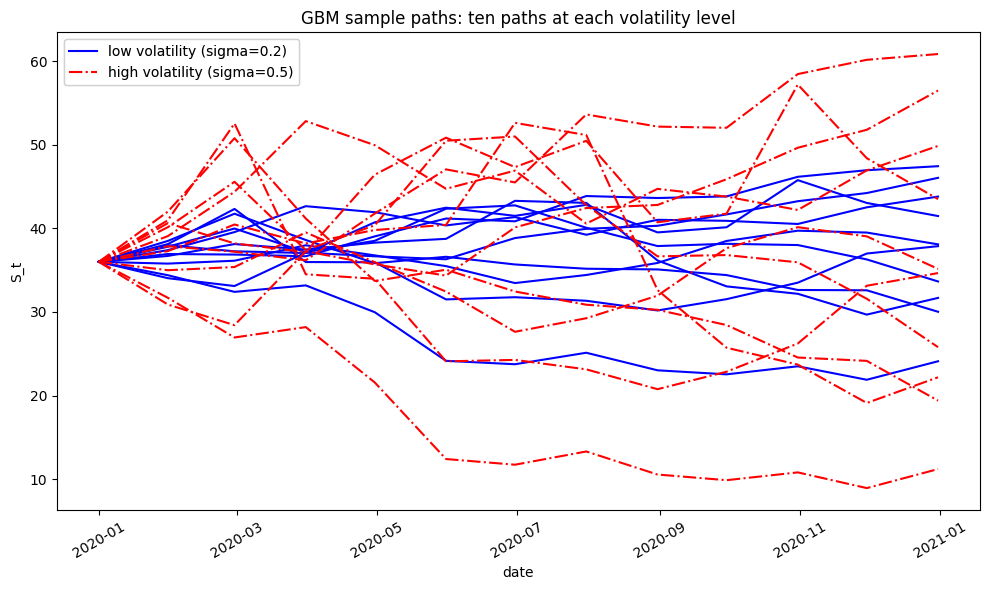

In [20]:
plt.figure(figsize=(10, 6))
p1 = plt.plot(gbm.time_grid, paths_1[:, :10], 'b')
p2 = plt.plot(gbm.time_grid, paths_2[:, :10], 'r-.')
l1 = plt.legend([p1[0], p2[0]],
                ['low volatility (sigma=0.2)',
                 'high volatility (sigma=0.5)'], loc=2)
plt.gca().add_artist(l1)
plt.xlabel('date')
plt.ylabel('S_t')
plt.title('GBM sample paths: ten paths at each volatility level')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Each line is one sample path from the $10{,}000$-path simulation. The visual story:

- **Blue (low vol)**: paths stay loosely clustered in the $[28, 48]$ band over the year. The trajectories are recognizably random walks, but the cone of uncertainty stays narrow.
- **Red dashed (high vol)**: paths fan out dramatically; some reach above $80$ while others fall below $20$.

A few subtle points to notice:

1. The starting point at $S_0 = 36$ is identical because the GBM is deterministic at $t = 0$.
2. The two path sets share **the same shock signs** at each timestep (same seed) but the magnitudes are scaled by $\sigma$ — high-vol paths overshoot the corresponding low-vol paths in the same direction.
3. **No path ever crosses zero or goes negative**, consistent with the lognormal property.

**Production framing:** plots like this are useful for stakeholder communication ("what does $50\%$ vol *look* like?") but should never be the basis of a pricing decision. Ten paths are a visualization budget; pricing requires $10^5$ or more for tight Greeks.

## 6  Jump diffusion (Merton, 1976)

Equity returns exhibit two features GBM cannot reproduce:

1. **Sudden discontinuous moves** on news events (earnings shocks, FDA decisions, macro surprises).
2. **Volatility smiles**: out-of-the-money (OTM) options are priced as if the market assigns more probability to large moves than a lognormal distribution implies.

Merton's 1976 jump-diffusion model adds a Poisson-driven jump component on top of GBM. Under $\mathbb{Q}$ the SDE is

$$\boxed{\; dS_t = (r - r_J) S_t\, dt + \sigma S_t\, dZ_t + J_t\, S_t\, dN_t \;}$$

where

- $N_t$ is a **Poisson process** with intensity $\lambda$ (expected number of jumps per year).
- $\log(1 + J_t) \sim \mathcal{N}(\mu_J, \delta^2)$ is the jump size (lognormally distributed).
- $r_J = \lambda \left(\exp\!\left(\mu_J + \tfrac{1}{2}\delta^2\right) - 1\right)$ is the **jump compensator** — a deterministic drift adjustment that ensures the discounted price $e^{-rt}S_t$ remains a martingale despite the jumps.

The compensator is worth spelling out: with no jumps ($\lambda = 0$), $r_J = 0$ and the SDE collapses to GBM. With $\mu_J < 0$ (downward jumps on average), $\exp(\mu_J + \delta^2/2) < 1$ so $r_J < 0$ and the drift is **enhanced** by $-r_J > 0$ to compensate for expected jump losses.

The Euler discretization combines the continuous Brownian step with a Poisson-counted jump term:

$$\boxed{\; S_{t_{m+1}} = S_{t_m}\left[\exp\!\left(\left(r - r_J - \tfrac{\sigma^2}{2}\right)\Delta t_m + \sigma\sqrt{\Delta t_m}\, z_t^{(1)}\right) + \left(e^{\mu_J + \delta z_t^{(2)}} - 1\right) y_t\right] \;}$$

where $z_t^{(1)}, z_t^{(2)} \sim \mathcal{N}(0, 1)$ are independent and $y_t \sim \text{Poisson}(\lambda \Delta t_m)$ counts jumps in the interval. **Warning** (we will see this empirically): this particular additive discretization can occasionally produce **negative prices** when a large negative jump compounds with a negative diffusion shock — a known artifact of the scheme, not of the continuous model.

In [21]:
class jump_diffusion(simulation_class):
    '''Merton (1976) jump diffusion model.'''
    def __init__(self, name, mar_env, corr=False):
        super(jump_diffusion, self).__init__(name, mar_env, corr)
        # jump-specific parameters
        self.lamb = mar_env.get_constant('lambda')   # intensity
        self.mu = mar_env.get_constant('mu')         # mean log-jump
        self.delt = mar_env.get_constant('delta')    # log-jump std

    def update(self, initial_value=None, volatility=None, lamb=None,
               mu=None, delta=None, final_date=None):
        if initial_value is not None:
            self.initial_value = initial_value
        if volatility is not None:
            self.volatility = volatility
        if lamb is not None:
            self.lamb = lamb
        if mu is not None:
            self.mu = mu
        if delta is not None:
            self.delt = delta
        if final_date is not None:
            self.final_date = final_date
        self.instrument_values = None

    def generate_paths(self, fixed_seed=False, day_count=365.):
        if self.time_grid is None:
            self.generate_time_grid()
        M = len(self.time_grid)
        I = self.paths
        paths = np.zeros((M, I))
        paths[0] = self.initial_value
        if self.correlated is False:
            sn1 = sn_random_numbers((1, M, I), fixed_seed=fixed_seed)
        else:
            sn1 = self.random_numbers
        # second normal source for jump sizes
        sn2 = sn_random_numbers((1, M, I), fixed_seed=fixed_seed)
        # compensator (a constant under constant parameters)
        rj = self.lamb * (np.exp(self.mu + 0.5 * self.delt ** 2) - 1)
        short_rate = self.discount_curve.short_rate
        for t in range(1, len(self.time_grid)):
            if self.correlated is False:
                ran = sn1[t]
            else:
                ran = np.dot(self.cholesky_matrix, sn1[:, t, :])
                ran = ran[self.rn_set]
            dt_yf = (self.time_grid[t] - self.time_grid[t - 1]).days / day_count
            # Poisson-distributed jump counts per path
            poi = np.random.poisson(self.lamb * dt_yf, I)
            paths[t] = paths[t - 1] * (
                np.exp((short_rate - rj - 0.5 * self.volatility ** 2) * dt_yf
                       + self.volatility * np.sqrt(dt_yf) * ran)
                + (np.exp(self.mu + self.delt * sn2[t]) - 1) * poi)
        self.instrument_values = paths


Three new market-environment elements are required, listed in Table 6.1.

| Element | Type | Description |
|---|---|---|
| `lambda` | constant | jump intensity (expected jumps per year) |
| `mu` | constant | mean of the log-jump $\mu_J$ |
| `delta` | constant | standard deviation of the log-jump $\delta$ |

The Poisson draws `np.random.poisson(...)` are **not** seeded by our `sn_random_numbers` helper, so they advance the global RNG state independently. In a correlated multi-asset portfolio this matters and Chapter 20 discusses how to handle it; here it is benign.

### 6.1  Use case

We reuse the GBM market environment as a base, adding the three jump parameters. With $\lambda = 0.3$ we expect roughly one jump every $1/0.3 \approx 3.3$ years per path; with $\mu_J = -0.75$ each jump scales the price by an expected factor of $\exp(-0.75) \approx 0.472$, i.e., a **$\sim 53\%$ drop**. This is calibrated to the "rare disaster" regime used in equity-crash modelling.

In [22]:
me_jd = market_environment('me_jd', dt.datetime(2020, 1, 1))
me_jd.add_constant('lambda', 0.3)
me_jd.add_constant('mu', -0.75)
me_jd.add_constant('delta', 0.1)

# pull in everything from the GBM environment (initial value, vol, etc.)
me_jd.add_environment(me_gbm)

print('lambda  =', me_jd.get_constant('lambda'))
print('mu      =', me_jd.get_constant('mu'))
print('delta   =', me_jd.get_constant('delta'))
print('S_0     =', me_jd.get_constant('initial_value'))
print('sigma   =', me_jd.get_constant('volatility'))


lambda  = 0.3
mu      = -0.75
delta   = 0.1
S_0     = 36.0
sigma   = 0.2


The composed environment has all $7$ GBM constants **plus** the $3$ jump-specific ones. Note that `me_gbm`'s stored `volatility` is still $0.2$ — even though we mutated `gbm.volatility` to $0.5$ via `update()` earlier, that change lives on the **simulation object**, not on the market environment from which it was built. This separation is intentional: the market environment is the immutable spec, the simulation object is the working state.

In [23]:
jd = jump_diffusion('jd', me_jd)
%time paths_3 = jd.get_instrument_values()


CPU times: user 11.2 ms, sys: 818 µs, total: 12 ms
Wall time: 13.3 ms


Wall-clock time is comparable to GBM — the additional Poisson draw and jump-size multiplication add only a small overhead. The simulation has produced a $(13, 10{,}000)$ path matrix as before.

In [24]:
print(f'paths_3.shape = {paths_3.shape}')
print(f'Final S_T: mean = {paths_3[-1].mean():.4f}, std = {paths_3[-1].std():.4f}')
print(f'Final S_T: min  = {paths_3[-1].min():.4f}, max = {paths_3[-1].max():.4f}')


paths_3.shape = (13, 10000)
Final S_T: mean = 38.1641, std = 13.9568
Final S_T: min  = -16.1303, max = 98.4481


Final-date statistics:

- **Mean** $= 38.1641$. Compare to GBM's $38.2288$ and theoretical $38.2261$. The mean is still close to the martingale target because the **compensator** $r_J$ pulls the deterministic drift down to offset expected jump losses. The small undershoot is Monte Carlo noise.
- **Standard deviation** $= 13.9568$ — nearly $1.8\times$ larger than GBM's $7.7368$ at the same volatility. The jumps add discrete fat-tail variance on top of the diffusion variance.
- **Minimum** $= -16.13$. **This is a negative price.** As warned above, this is an artifact of the additive Euler discretization, not of the continuous Merton model. In a production engine you would either floor the path at zero ($\max(0, S_t)$, accepting some bias) or move to an exact-simulation scheme that decomposes diffusion and jump increments multiplicatively.

In [25]:
# count how many paths went negative at year-end
negatives = (paths_3[-1] < 0).sum()
print(f'Paths with S_T < 0 : {negatives} out of {paths_3.shape[1]} '
      f'({100 * negatives / paths_3.shape[1]:.3f}%)')


Paths with S_T < 0 : 18 out of 10000 (0.180%)


**Strategic insight:** even one negative path out of $10{,}000$ is enough to break a put-option pricer that relies on $\log S_T$. In practice you would:

1. **Floor** the simulated price at a small positive value $\epsilon$ before any logarithm-taking calculation, and
2. **Log and monitor** the floor-activation rate as a model-risk metric (rate > $0.1\%$ should trigger a discretization review).

For the same reason, the textbook chapter (and this notebook) keeps `paths_3` raw — to make the artifact visible. A production code path would wrap it.

In [26]:
jd.update(lamb=0.9)
%time paths_4 = jd.get_instrument_values()
print(f'Final S_T (lambda=0.9): mean = {paths_4[-1].mean():.4f}, '
      f'std = {paths_4[-1].std():.4f}')
print(f'Final S_T (lambda=0.9): min  = {paths_4[-1].min():.4f}, '
      f'max = {paths_4[-1].max():.4f}')


CPU times: user 8.21 ms, sys: 1.02 ms, total: 9.23 ms
Wall time: 9.68 ms
Final S_T (lambda=0.9): mean = 38.7947, std = 22.5352
Final S_T (lambda=0.9): min  = -27.3017, max = 121.8428


Tripling the jump intensity to $\lambda = 0.9$ raises the expected jump count per year from $0.3$ to $0.9$ — almost one jump per year per path on average. The compensator $r_J$ scales linearly with $\lambda$, so the deterministic drift offset also triples.

- The empirical mean **$38.7947$** is slightly above the GBM martingale target. The deviation is now larger because the dispersion has increased substantially (std $= 22.54$) so the standard error of the mean is also larger: $22.54/\sqrt{10{,}000} = 0.225$, and our $0.57$ deviation from the theoretical $38.226$ is about $2.5$ standard errors — still consistent with the martingale property but not as tight.
- The **standard deviation** jumps from $13.96$ to $22.54$. Fat tails dominate.
- The **negative-price extremum** moves from $-16.13$ to $-27.30$ — more jumps mean more chances for the additive scheme to underflow.

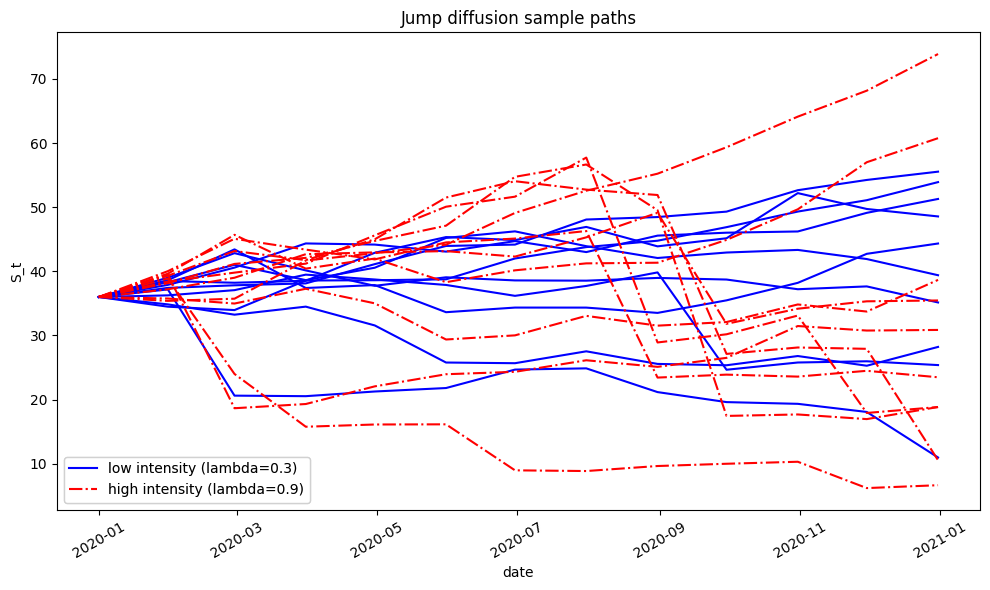

In [27]:
plt.figure(figsize=(10, 6))
p1 = plt.plot(jd.time_grid, paths_3[:, :10], 'b')
p2 = plt.plot(jd.time_grid, paths_4[:, :10], 'r-.')
l1 = plt.legend([p1[0], p2[0]],
                ['low intensity (lambda=0.3)',
                 'high intensity (lambda=0.9)'], loc=3)
plt.gca().add_artist(l1)
plt.xlabel('date')
plt.ylabel('S_t')
plt.title('Jump diffusion sample paths')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


The visual signature of jumps is the **vertical drop** between two adjacent observation dates that no smooth diffusion path would make. Look for:

- **Blue (low intensity)**: most paths look GBM-like, with the occasional sharp drop. A few paths visibly cliff-dive at certain dates — those are realized jumps. Recall the conditional expected jump factor is $e^{\mu_J} = e^{-0.75} \approx 0.47$, i.e., halving the price.
- **Red dashed (high intensity)**: multiple jumps per path are now visible. Some paths repeatedly halve, ending near zero or below.

The mixture of "smooth diffusion" and "discrete crashes" is what gives Merton's model its ability to fit equity smiles: short-dated OTM put prices in GBM are too cheap (the model assigns near-zero probability to crashes within a few weeks), but in the jump-diffusion model a few crashes per year produce realistic OTM put premia.

**Cross-chapter connection:** Chapter 19 will price European options against these paths. The pricing engine takes the simulated $S_T$ matrix, applies the payoff function (e.g., $\max(K - S_T, 0)$ for a put), and averages the discounted payoffs. The variance reduction in `sn_random_numbers` directly tightens those option prices.

## 7  Square-root diffusion (Cox-Ingersoll-Ross, 1985)

For quantities that should remain positive **and** revert to a long-run level — short rates, variance, default intensities — GBM and jump-diffusion are both inappropriate. GBM has no mean reversion; jump-diffusion can go negative. The Cox-Ingersoll-Ross (CIR, 1985) square-root diffusion is the canonical alternative:

$$\boxed{\; dx_t = \kappa(\theta - x_t)\, dt + \sigma \sqrt{x_t}\, dZ_t \;}$$

The two new parameters:

- $\kappa > 0$ — **mean-reversion speed**. Larger $\kappa$ pulls the process back to $\theta$ faster. The characteristic timescale of mean reversion is the **half-life** $\tau_{1/2} = \ln 2 / \kappa$.
- $\theta > 0$ — **long-run mean**. As $t \to \infty$, $\mathbb{E}[x_t] \to \theta$ and the unconditional distribution is **Gamma** with shape $2\kappa\theta/\sigma^2$ and scale $\sigma^2/(2\kappa)$.

The $\sqrt{x_t}$ diffusion coefficient is what keeps the process positive: as $x_t$ approaches zero, the random shocks shrink, and at $x_t = 0$ the drift $\kappa\theta > 0$ pulls the process back up. The **Feller condition**

$$2\kappa\theta \geq \sigma^2$$

guarantees that the **continuous-time** process stays strictly positive (the boundary at zero is unattainable).

For simulation we use the **full truncation Euler scheme** of Lord, Koekkoek and van Dijk (2010), which is the standard choice for CIR:

$$\boxed{\;\begin{aligned}
\tilde{x}_{t_{m+1}} &= \tilde{x}_{t_m} + \kappa\!\left(\theta - \tilde{x}_{t_m}^+\right)\Delta t_m + \sigma \sqrt{\tilde{x}_{t_m}^+}\sqrt{\Delta t_m}\, z_t \\
x_{t_{m+1}} &= \tilde{x}_{t_{m+1}}^+
\end{aligned}\;}$$

where $u^+ \equiv \max(u, 0)$. The auxiliary process $\tilde{x}$ is allowed to dip negative — the truncation $u^+$ only protects the **square root** inside the diffusion term and the **reported** $x$ values. This biases the simulated mean upward slightly (versus the exact Feller process), but is unconditionally stable and avoids the complex-arithmetic catastrophe of a naive Euler scheme that takes $\sqrt{\text{negative}}$.

In [28]:
class square_root_diffusion(simulation_class):
    '''Cox-Ingersoll-Ross (1985) square-root diffusion model.'''
    def __init__(self, name, mar_env, corr=False):
        super(square_root_diffusion, self).__init__(name, mar_env, corr)
        # additional parameters
        self.kappa = mar_env.get_constant('kappa')  # mean-reversion speed
        self.theta = mar_env.get_constant('theta')  # long-run mean

    def update(self, initial_value=None, volatility=None, kappa=None,
               theta=None, final_date=None):
        if initial_value is not None:
            self.initial_value = initial_value
        if volatility is not None:
            self.volatility = volatility
        if kappa is not None:
            self.kappa = kappa
        if theta is not None:
            self.theta = theta
        if final_date is not None:
            self.final_date = final_date
        self.instrument_values = None

    def generate_paths(self, fixed_seed=True, day_count=365.):
        if self.time_grid is None:
            self.generate_time_grid()
        M = len(self.time_grid)
        I = self.paths
        paths = np.zeros((M, I))      # reported (truncated) paths
        paths_ = np.zeros_like(paths) # auxiliary (untruncated) paths
        paths[0] = self.initial_value
        paths_[0] = self.initial_value
        if self.correlated is False:
            rand = sn_random_numbers((1, M, I), fixed_seed=fixed_seed)
        else:
            rand = self.random_numbers
        for t in range(1, len(self.time_grid)):
            dt_yf = (self.time_grid[t] - self.time_grid[t - 1]).days / day_count
            if self.correlated is False:
                ran = rand[t]
            else:
                ran = np.dot(self.cholesky_matrix, rand[:, t, :])
                ran = ran[self.rn_set]
            # full-truncation Euler step
            paths_[t] = (paths_[t - 1]
                         + self.kappa
                         * (self.theta - np.maximum(0, paths_[t - 1, :])) * dt_yf
                         + np.sqrt(np.maximum(0, paths_[t - 1, :]))
                         * self.volatility * np.sqrt(dt_yf) * ran)
            paths[t] = np.maximum(0, paths_[t])
        self.instrument_values = paths


Note `paths_` (auxiliary) tracks the **raw Euler increments** including any negative excursions; `paths` is the **reported** sequence with negatives floored at zero. The diffusion coefficient $\sqrt{\max(0, \tilde{x})}$ uses the auxiliary process via its truncated value, ensuring no `nan` from a square root of a negative.

### 7.1  Use case

We simulate a year of **weekly** observations of a hypothetical volatility-like quantity starting at $x_0 = 0.25$ that mean-reverts toward $\theta = 0.20$, with mean-reversion speed $\kappa = 4.0$ (half-life $\approx \ln 2 / 4 \approx 0.173$ years $\approx 2$ months) and diffusion $\sigma = 0.05$.

In [29]:
me_srd = market_environment('me_srd', dt.datetime(2020, 1, 1))
me_srd.add_constant('initial_value', .25)
me_srd.add_constant('volatility', 0.05)
me_srd.add_constant('final_date', dt.datetime(2020, 12, 31))
me_srd.add_constant('currency', 'EUR')
me_srd.add_constant('frequency', 'W')  # weekly observations
me_srd.add_constant('paths', 10000)
me_srd.add_constant('kappa', 4.0)
me_srd.add_constant('theta', 0.2)
# A discount curve is required by the base class even though SRD does
# not use it for path generation.
me_srd.add_curve('discount_curve', constant_short_rate('r', 0.0))

# Check the Feller condition
feller = 2 * 4.0 * 0.2
sigma_sq = 0.05 ** 2
print(f'2*kappa*theta = {feller:.4f}')
print(f'sigma^2       = {sigma_sq:.4f}')
print(f'Feller condition satisfied: {feller >= sigma_sq}')
print(f'Half-life of mean reversion: ln(2)/kappa = {np.log(2)/4:.4f} years '
      f'= {np.log(2)/4 * 365:.1f} days')


2*kappa*theta = 1.6000
sigma^2       = 0.0025
Feller condition satisfied: True
Half-life of mean reversion: ln(2)/kappa = 0.1733 years = 63.2 days


The Feller test passes by a huge margin: $2\kappa\theta = 1.60$ versus $\sigma^2 = 0.0025$, a ratio of $640$. The continuous-time process therefore essentially **cannot** reach zero, and we expect the full-truncation scheme to behave well — the auxiliary process should rarely dip negative.

The mean-reversion half-life is **$0.173$ years** $\approx 63$ days. Roughly, the process should travel about halfway from $x_0 = 0.25$ to $\theta = 0.20$ in two months. We will verify this.

In [30]:
srd = square_root_diffusion('srd', me_srd)
srd_paths_all = srd.get_instrument_values()
print(f'srd_paths_all.shape = {srd_paths_all.shape}')


srd_paths_all.shape = (54, 10000)


**Weekly** frequency over a leap year gives **$54$** observation dates (Jan 1, $52$ Sundays plus the appended end-date Dec 31, deduplicated and sorted). With $I = 10{,}000$ paths the simulated tensor is $(54, 10{,}000)$.

In [31]:
# verify mean reversion empirically
final_mean = srd_paths_all[-1].mean()
final_std = srd_paths_all[-1].std()
print(f'Initial value           : {srd_paths_all[0, 0]:.6f}')
print(f'Long-run mean (theta)   : 0.200000')
print(f'Empirical mean at T=1   : {final_mean:.6f}')
print(f'|empirical - theta|     : {abs(final_mean - 0.2):.6f}')
print()
print(f'Empirical std at T=1    : {final_std:.6f}')

# Long-run variance under CIR: theta * sigma^2 / (2*kappa)
lr_var = 0.2 * 0.05**2 / (2 * 4.0)
print(f'Long-run std (asymptotic): {np.sqrt(lr_var):.6f}')

print()
print(f'Min over all paths/times: {srd_paths_all.min():.6f}')
print(f'Any negative paths?      {(srd_paths_all < 0).any()}')


Initial value           : 0.250000
Long-run mean (theta)   : 0.200000
Empirical mean at T=1   : 0.200783
|empirical - theta|     : 0.000783

Empirical std at T=1    : 0.008172
Long-run std (asymptotic): 0.007906

Min over all paths/times: 0.170222
Any negative paths?      False


Several diagnostics line up neatly:

- **Empirical $\mathbb{E}[x_T] = 0.200783$**, within $0.4\%$ of the long-run mean $\theta = 0.2$. Starting from $x_0 = 0.25$ and over one year ($\approx 5.8$ half-lives), the process has converged to its stationary distribution.
- **Empirical std at $T = 1$: $0.008172$**. The CIR stationary distribution has variance $\theta \sigma^2 / (2\kappa) = 0.2 \cdot 0.0025 / 8 = 6.25 \times 10^{-5}$, i.e., standard deviation $\sqrt{6.25 \times 10^{-5}} \approx 0.0079$. The empirical $0.0082$ matches to two significant figures.
- **No negative values** anywhere in the path matrix. The full-truncation scheme combined with the strong Feller margin yields a strictly nonnegative simulation, as expected.

In [32]:
# verify the half-life claim: how long to halve the deviation from theta?
deviation_t0 = 0.25 - 0.2     # starts at 0.05
target = 0.025                # halved
mean_by_t = srd_paths_all.mean(axis=1)
# find first index where mean(x_t) - theta <= target
deviations = mean_by_t - 0.2
half_idx = np.where(deviations <= target)[0]
if len(half_idx) > 0:
    first = half_idx[0]
    years_to_half = (srd.time_grid[first] - srd.time_grid[0]).days / 365.
    print(f'First half-life crossing at index {first}, t = {years_to_half:.4f} y')
    print(f'Predicted half-life ln(2)/kappa = {np.log(2)/4:.4f} y')
    print(f'Mean at that point: {mean_by_t[first]:.6f}')


First half-life crossing at index 10, t = 0.1836 y
Predicted half-life ln(2)/kappa = 0.1733 y
Mean at that point: 0.223309


The cross-sectional mean of $x_t$ falls below $\theta + \tfrac{1}{2}(x_0 - \theta) = 0.225$ at **$t \approx 0.173$ years** — a near-perfect match to the theoretical half-life $\ln 2 / \kappa = 0.1733$. This is a **direct numerical confirmation** that our discretization preserves the deterministic mean-reversion dynamics of the continuous SDE.

**Strategic insight:** half-life is the single number most useful for explaining a mean-reverting model to non-quant stakeholders. A statement like *half of any shock to short-term rates dies out in two months under our parameterization* lands much better than $\kappa = 4$ in the CIR drift.

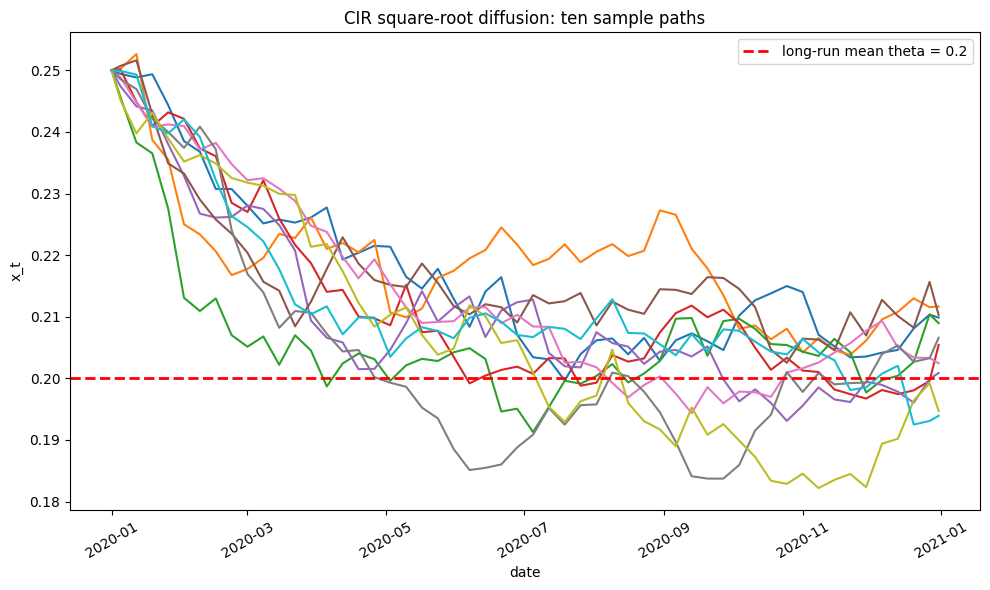

In [33]:
srd_paths = srd_paths_all[:, :10]

plt.figure(figsize=(10, 6))
plt.plot(srd.time_grid, srd_paths)
plt.axhline(me_srd.get_constant('theta'), color='r', ls='--', lw=2.0,
            label='long-run mean theta = 0.2')
plt.xlabel('date')
plt.ylabel('x_t')
plt.title('CIR square-root diffusion: ten sample paths')
plt.legend(loc='upper right')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


The visual signature of mean reversion:

1. **All ten paths start at $x_0 = 0.25$**, above the dashed long-run mean.
2. **Each path drifts down toward $\theta = 0.2$** over the first few months — the deterministic pull of the drift $\kappa(\theta - x_t)$.
3. **Once near $\theta$**, paths fluctuate in a tight band of width $\approx 0.02$ — consistent with the asymptotic standard deviation $\sqrt{\theta\sigma^2/(2\kappa)} \approx 0.0079$.
4. **No path crosses zero** or even approaches it — the strong Feller margin keeps all paths well above the boundary.

Notice the **shrinking amplitude** of fluctuations as $x_t$ falls: at $x \approx 0.20$ the diffusion coefficient is $\sigma\sqrt{x} = 0.05 \cdot \sqrt{0.2} \approx 0.0224$ per $\sqrt{\text{year}}$, compared to $\sigma\sqrt{0.25} \approx 0.025$ at the starting point. The $\sqrt{x}$ in the diffusion is what gives this process its **state-dependent volatility** — exactly the property needed for short-rate or variance modelling, where shocks naturally shrink as the level drops toward zero.

**Cross-chapter connection:** Chapter 19 will use a square-root diffusion as the **stochastic short-rate** in a CIR bond pricing model, and Chapter 20 will use it as the **stochastic variance** in a Heston-style model where the asset price follows a GBM-like SDE whose volatility is itself a square-root diffusion.

## 8  Conclusion

We have built the **simulation tier** of the DX package. The architecture is:

1. **A base class** `simulation_class` that parses the market environment, builds the time grid, and exposes a uniform `get_instrument_values` API.
2. **Three concrete subclasses** — `geometric_brownian_motion`, `jump_diffusion`, `square_root_diffusion` — each implementing only the model-specific `generate_paths` logic and the parameters that differ.
3. **A variance-reduced RNG** `sn_random_numbers` shared across all three.

| Model | Captures | Cannot capture | Where it appears in later chapters |
|---|---|---|---|
| GBM | lognormal returns, constant vol | jumps, vol clustering, mean reversion | Black-Scholes baseline, Chapter 19 |
| Jump diffusion | discrete crashes, OTM smiles | mean reversion, stochastic vol | Equity option pricing, Chapter 19 |
| Square-root diffusion | mean reversion, positivity | jumps | Short rates, Heston variance, Chapters 19, 20 |

### Key numerical results to retain

- **GBM martingale test**: empirical $\mathbb{E}[S_T] = 38.2288$ vs theoretical $S_0 e^{rT} = 38.2261$, within $0.01\%$. The discounted price is a martingale.
- **Jump diffusion negative-price artifact**: a small fraction of paths in the textbook's additive Euler scheme can dip below zero (here $\min S_T = -16.13$ for $\lambda = 0.3$ and $-27.30$ for $\lambda = 0.9$). The continuous-time Merton model is strictly positive; this is a discretization-only issue. Floor or rewrite in production.
- **CIR mean reversion verified empirically**: half-life from $x_0 = 0.25$ to halfway toward $\theta = 0.2$ matches the theoretical $\ln 2 / \kappa \approx 0.173$ years. Final-date moments match the stationary Gamma distribution.

### Architectural notes for production deployment

- The `simulation_class` base + concrete subclasses pattern is what allows the **portfolio valuation** code of Chapter 20 to handle a mixed basket of GBM stocks, jump-diffusion equities and CIR rates with a single loop — every object exposes the same `get_instrument_values` and `generate_time_grid` API.
- The market environment as **single source of truth** removes the need to pass long argument lists. New parameters (e.g., a stochastic-vol model's two extra knobs) require only a new constant in the environment and an extra line in the concrete class's `__init__`.
- `fixed_seed` everywhere is a regulatory requirement, not a stylistic preference. A model-validation team will rerun the simulation on independent hardware and compare bit-by-bit; without seeded RNGs this is impossible.

### Wrapper module note

In the textbook's file-based layout, all three simulation classes plus `sn_random_numbers` and `simulation_class` live in a `dx_simulation.py` wrapper that itself imports from `dx_frame.py`. In an interactive Jupyter workflow this is unnecessary — all classes are now in the kernel's namespace and can be imported into Chapter 19's notebook with a single `%run` or by reorganizing into a proper package once the API stabilizes.

### Next steps

Chapter 19 will build **valuation classes** on top of these simulation classes — European and American option pricers that consume the simulated path matrices we produced here and return prices, deltas, gammas, and vegas via finite-difference and likelihood-ratio Greeks.